In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [152]:
# Lee el archivo normalmente
df = pd.read_csv("afluencia_metro_cdmx.csv", encoding='utf-8')

# Reemplazo manual de los caracteres problemáticos (completo)
replacements = {
    'Ã¡': 'á',
    'Ã©': 'é', 
    'Ã­': 'í',  
    'Ã³': 'ó',
    'Ãº': 'ú',
    'Ã±': 'ñ',
}

# Aplica los reemplazos en las columnas de texto
for col in df.select_dtypes(include=['object']).columns:
    for old, new in replacements.items():
        df[col] = df[col].astype(str).str.replace(old, new, regex=False)

In [153]:
df.head(20)

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499
5,2010-01-01,2010,Enero,Linea 6,Deportivo 18 de Marzo,621
6,2010-01-01,2010,Enero,Linea 6,La Villa/Basílica,24792
7,2010-01-01,2010,Enero,Linea 9,Pantitlán,27000
8,2010-01-01,2010,Enero,Linea 8,Aculco,3652
9,2010-01-01,2010,Enero,Linea 9,Velódromo,3239


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162980 entries, 0 to 1162979
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1162980 non-null  object
 1   anio       1162980 non-null  int64 
 2   mes        1162980 non-null  object
 3   linea      1162980 non-null  object
 4   estacion   1162980 non-null  object
 5   afluencia  1162980 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 53.2+ MB


In [155]:
# ----- Tamaño del Data Frame -----
print(f"El Data Frame tiene {df.shape[0]:,.2f} filas")
print(f"El Data Frame tiene {df.shape[1]:.0f} columnas")

El Data Frame tiene 1,162,980.00 filas
El Data Frame tiene 6 columnas


In [156]:
df["linea"].value_counts()

linea
Linea 2     121992
Linea 3     106743
Linea B     106743
Linea 1     101660
Linea 12    101660
Linea 8      96577
Linea 7      71162
Linea 5      66079
Linea 9      60996
Linea 6      55913
Linea 4      50830
Linea A      50830
Línea 2      21144
Línea 3      18501
Línea B      18501
Línea 12     17620
Línea 1      17620
Línea 8      16739
Línea 7      12334
Línea 5      11453
Línea 9      10572
Línea 6       9691
Línea 4       8810
Línea A       8810
Name: count, dtype: int64

En este caso tenemos el problema de que algunas lineas del metro tienen acento y otras,están escritas de forma diferente:
* `"Linea 2"` (sin acento) = 121,992 registros
* `"Línea 2"` (con acento) = 21,144 registros

In [157]:
# ----- Quitamos el acento a las lineas que lo tienen para tener todos los nombres en orden -----
# Reemplazar "Línea" por "Linea" (quitar acentos)
df["linea"] = df["linea"].str.replace("Línea", "Linea", regex=False)

# Usamos "lower()" para estandarizar a minúsculas
df["linea"] = df["linea"].str.lower() # o str.upper()

# Mostramos los valores de la columna "linea" con los cambios
afluencia_doce_lineas = df["linea"].value_counts()
afluencia_doce_lineas

linea
linea 2     143136
linea 3     125244
linea b     125244
linea 1     119280
linea 12    119280
linea 8     113316
linea 7      83496
linea 5      77532
linea 9      71568
linea 6      65604
linea 4      59640
linea a      59640
Name: count, dtype: int64

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_2123/2976181817.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=suma_numero_personas_linea.index,


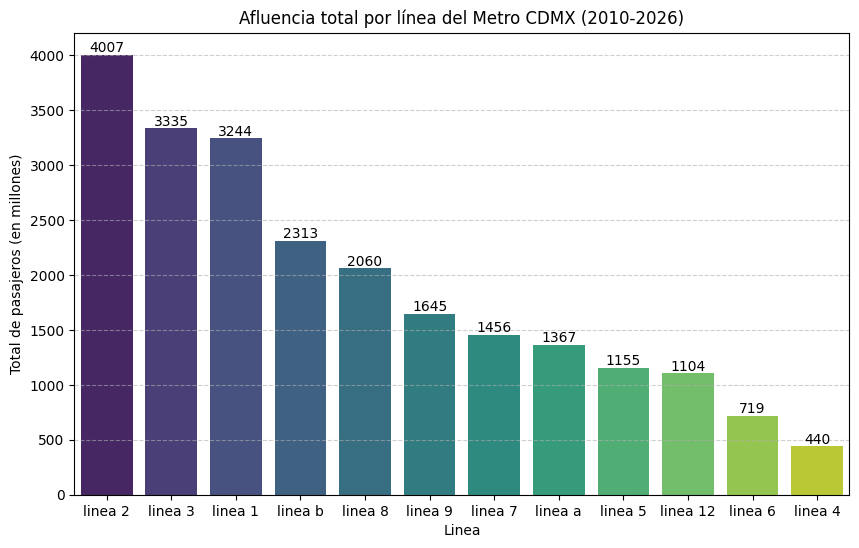

In [165]:
# ----- Graficamos el número de personas que utilizan una de las doce lineas del metro -----
# Esto SUMA la afluencia (número de personas)
suma_numero_personas_linea = df.groupby('linea')['afluencia'].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10,6))
barras = sns.barplot(x=suma_numero_personas_linea.index,
            y=suma_numero_personas_linea.values / 1_000_000,
            palette="viridis")
# Agregamos el número de personas en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.title("Afluencia total por línea del Metro CDMX (2010-2026)")
plt.xlabel("Linea")
plt.ylabel('Total de pasajeros (en millones)')
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()